# Assignment 2 - Text Classification

Let's examine text classification with a variety of network architectures.  While doing this we'll also train some models and try to avoid overfitting.  We'll also look at some efficiencies in training.

This notebook consists of three separate sections.  Prior to runnning the third part, you must stop and disconnect the runtime and then restart the notebook.
The third section is self-sufficeint, meaning that you can run it without running sections 1 and 2 first.

The overall assignment structure is as follows:


0. Setup
  
    0.1 Libraries, Embeddings,  & Helper Functions

    0.2 Data Acquisition

    0.3. Data Preparation

        0.3.1 Training/Test Sets using Word2Vec

        0.3.2 Training/Test Sets for BERT-based models


1. Classification with various Word2Vec-based Models

    1.1 The Role of Shuffling of the Training Set

    1.2 DAN
    
    1.3 Approaches for Training of Embeddings

2. Text Classification with Convolutional Neural Networks

    2.0. Setup

    2.1. Creation of the Dataset  

    2.2. Modeling

    2.3 Fix Convolutional Neural Net (CNN) Over Fitting

3. Text Classification with BERT

    3.0. Setup
  
        3.0.1 Libraries and Helper Functions

        3.0.2 Data Acquisition

        3.0.3. Data Preparation


    3.1. Classification with BERT

        3.1.1 BERT Basics

        3.1.2 Testing Pre-trained BERT models  

        3.1.3 Unfreezing layers in training


**Description:** This assignment covers various neural network architectures and components, largely used in the context of classification. You will compare Deep Averaging Networks, Convolutional Neural Networks, and BERT-based models.


The assignment notebook closely follows the lesson notebooks. We will again use the IMDB dataset and will leverage some of the models, or part of the code, for our current investigation.

**INSTRUCTIONS:**

* Questions in this notebook are always indicated as **QUESTION**, so you can search for this string to make sure you answered all of the questions. You are expected to fill out, run, and submit this notebook, as well as to answer the questions in the Gradescope **answers** file.  Please do **not** remove the output from your notebooks when you submit them as we'll look at the output as well as your code for grading purposes.  **We cannot award points if the output cells are empty.**

* **### YOUR CODE HERE** indicates that you are supposed to write code.

* If you want to, you can run all of the cells in section 0 in bulk. This is setup work and no questions are in there. At the end of section 0 we will state all of the relevant variables that were defined and created in section 1.

* Finally, unless otherwise indicated your validation accuracy will be 0.65 or higher if you have correctly implemented the model.


* **### --- Put your answer in Gradescope Q.0. Do not enter your answer here. --- ###** indicates where in the Gradescope answer sheet you are supposed to write your answer. Please put your answer in the requested format.  Some questions are multiple choice so you can select the appropriate answer. Other questions are fill in the blank so enter either a string or a raw number -- no executable code, for example "3,15,24" or 0.123 but **NOT** `dict[23]` or `my_variable_name`.

**GRADESCOPE:**
- We are **NOT** using the autograder for this assignment.
- We are using a Gradescope answer sheet to facilitate grading.

- The assignment notebook you submit must be named Assignment_2.ipynb.  The very last question asks you to upload your notebook.

- Please format your input and output strings to be user friendly
- Adding comments in your code is strongly suggested but won't be graded.
- If you are stuck on a problem or do not understand a question - please come to office hours or ask questions (please don't post your code though). If it is a coding problem send a private email to your instructor.
- You can ask TAs for extra help and 1 on 1 sessions!
- You may use any libraries from the Python Standard Library for this assignment: https://docs.python.org/3/library/

**REMINDER:**
You must cite all of your uses of AI to assist in the homework.  A space is provided at the very end of the notebook to do so.

## 0. Setup

### 0.1. Libraries and Helper Functions

This notebook requires the TensorFlow dataset and other prerequisites that you must download.  THis model uses the Keras 3 interface.

In [51]:
#@title Installs
!pip install pydot --quiet
!pip install gensim --quiet
!pip install tensorflow-datasets --quiet
!pip install tensorflow-text --quiet


In [52]:
!pip install -q -U keras

In [53]:
!pip install -U -q protobuf

In [54]:
!pip install -q importlib_resources

In [55]:
!python -V

Python 3.13.15


Now we are ready to do the imports.

In [56]:
#@title Imports
import os

os.environ["KERAS_BACKEND"] = "torch"

import numpy as np
import torch
import tensorflow as tf
import keras

from keras.layers import Embedding, Input, Dense, Lambda
from keras.models import Model

import tensorflow_datasets as tfds
import tensorflow_text as tf_text


import sklearn as sk

import nltk
from nltk.data import find

import matplotlib.pyplot as plt

import re

import gensim
from gensim.models import Word2Vec
from gensim.models import KeyedVectors
from gensim.test.utils import datapath

In [57]:
def print_version(library_name):
    try:
        lib = __import__(library_name)
        version = getattr(lib, '__version__', 'Version number not found')
        print(f"{library_name} version: {version}")
    except ImportError:
        print(f"{library_name} not installed.")
    except Exception as e:
        print(f"An error occurred: {e}")


In [58]:
#confirm versions
print_version('numpy')
print_version('torch')
print_version('keras')
print_version('nltk')
print_version('gensim')

numpy version: 2.1.3
torch version: 2.11.0+cu128
keras version: 3.15.1
nltk version: 3.9.1
gensim version: 4.4.0


Make sure you are using a Keras version > 3.0 and a torch version > 2.7 for this notebook.

Below is a helper function to plot histories.

In [59]:
#@title Plotting Function

# 4-window plot. Small modification from matplotlib examples.

def make_plot(axs,
              model_history1,
              model_history2,
              model_1_name='model 1',
              model_2_name='model 2',
              ):
    box = dict(facecolor='yellow', pad=5, alpha=0.2)

    for i, metric in enumerate(['loss', 'accuracy']):
        # small adjustment to account for the 2 accuracy measures in the Weighted Averging Model with Attention
        if 'classification_%s' % metric in model_history2.history:
            metric2 = 'classification_%s' % metric
        else:
            metric2 = metric

        y_lim_lower1 = np.min(model_history1.history[metric])
        y_lim_lower2 = np.min(model_history2.history[metric2])
        y_lim_lower = min(y_lim_lower1, y_lim_lower2) * 0.9

        y_lim_upper1 = np.max(model_history1.history[metric])
        y_lim_upper2 = np.max(model_history2.history[metric2])
        y_lim_upper = max(y_lim_upper1, y_lim_upper2) * 1.1

        for j, model_history in enumerate([model_history1, model_history2]):
            model_name = [model_1_name, model_2_name][j]
            model_metric = [metric, metric2][j]
            ax1 = axs[i, j]
            ax1.plot(model_history.history[model_metric])
            ax1.plot(model_history.history['val_%s' % model_metric])
            ax1.set_title('%s - %s' % (metric, model_name))
            ax1.set_ylabel(metric, bbox=box)
            ax1.set_ylim(y_lim_lower, y_lim_upper)

Next, we get the word2vec model from NLTK to use as our embeddings.

In [60]:
#@title NLTK & Word2Vec

nltk.download('word2vec_sample')

word2vec_sample = str(find('models/word2vec_sample/pruned.word2vec.txt'))

wvmodel = KeyedVectors.load_word2vec_format(datapath(word2vec_sample), binary=False)

[nltk_data] Downloading package word2vec_sample to /root/nltk_data...
[nltk_data]   Package word2vec_sample is already up-to-date!


Now here we have the embedding **model** defined, let's see how many words are in the vocabulary:

In [61]:
len(wvmodel)

43981

What do the word vectors look like? As expected:

In [62]:
wvmodel['great'][:20]

array([ 0.0306035 ,  0.0886877 , -0.0121269 ,  0.0761965 ,  0.0566269 ,
       -0.0424702 ,  0.0410129 , -0.0497567 , -0.00364328,  0.0632889 ,
       -0.0142608 , -0.0791111 ,  0.0174877 , -0.0383064 ,  0.00926433,
        0.0295626 ,  0.0770293 ,  0.0949334 , -0.0428866 , -0.0295626 ],
      dtype=float32)

We can now build the embedding matrix and a vocabulary dictionary:

In [63]:
EMBEDDING_DIM = len(wvmodel['university'])      # we know... it's 300

# initialize embedding matrix and word-to-id map:
embedding_matrix = np.zeros((len(wvmodel) + 1, EMBEDDING_DIM))
vocab_dict = {}

# build the embedding matrix and the word-to-id map:
for i, word in enumerate(wvmodel.index_to_key):
    embedding_vector = wvmodel[word]

    if embedding_vector is not None:
        # words not found in embedding index will be all-zeros.
        embedding_matrix[i] = embedding_vector
        vocab_dict[word] = i

# we can use the last index at the end of the vocab for unknown tokens
vocab_dict['[UNK]'] = len(vocab_dict)

In [64]:
embedding_matrix.shape

(43982, 300)

In [65]:
embedding_matrix[:5, :5]

array([[ 0.0891758 ,  0.121832  , -0.0671959 ,  0.0477279 , -0.013659  ],
       [ 0.0526281 ,  0.013157  , -0.010104  ,  0.0540819 ,  0.0386715 ],
       [ 0.0786419 ,  0.0373911 , -0.0131472 ,  0.0347375 ,  0.0288273 ],
       [-0.00157585, -0.0564239 ,  0.00320281,  0.0422498 ,  0.15264399],
       [ 0.0356899 , -0.00367283, -0.065534  ,  0.0213832 ,  0.00788408]])

The last row consists of all zeros. We will use that for the UNK token, the placeholder token for unknown words.

### 0.2 Data Acquisition


We will use the IMDB dataset delivered as part of the TensorFlow-datasets library, and split into training and test sets. For expedience, we will limit ourselves in terms of train and test examples.

In [66]:
train_data, test_data = tfds.load(
    name="imdb_reviews",
    split=('train[:80%]', 'test[80%:]'),
    as_supervised=True)

train_examples, train_labels = next(iter(train_data.batch(20000)))
test_examples, test_labels = next(iter(test_data.batch(5000)))

It is always highly recommended to look at the data. What do the records look like? Are they clean or do they contain a lot of cruft (potential noise)?

In [67]:
train_examples[:4]

<tf.Tensor: shape=(4,), dtype=string, numpy=
array([b"This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it.",
       b'I have been known to fall asleep during films, but this is usually due to a combination of things including, really tired, being warm and comfortable on the sette and having just eaten a lot. However on this occasion I fell a

In [68]:
train_labels[:4]

<tf.Tensor: shape=(4,), dtype=int64, numpy=array([0, 0, 0, 1])>

For convenience, in this assignment we will define a sequence length and truncate all records at that length. For records that are shorter than our defined sequence length we will add padding characters to insure that our input shapes are consistent across all records.

In [113]:
MAX_SEQUENCE_LENGTH = 100

### 0.3. Data Preparation

#### 0.3.1. Training/Test Sets for Word2Vec-based Models

First, we tokenize the data:

In [70]:
tokenizer = tf_text.WhitespaceTokenizer()
train_tokens = tokenizer.tokenize(train_examples)
test_tokens = tokenizer.tokenize(test_examples)

Let's look at some tokens.  Do they look acceptable?

In [71]:
train_tokens[0]

<tf.Tensor: shape=(116,), dtype=string, numpy=
array([b'This', b'was', b'an', b'absolutely', b'terrible', b'movie.',
       b"Don't", b'be', b'lured', b'in', b'by', b'Christopher', b'Walken',
       b'or', b'Michael', b'Ironside.', b'Both', b'are', b'great',
       b'actors,', b'but', b'this', b'must', b'simply', b'be', b'their',
       b'worst', b'role', b'in', b'history.', b'Even', b'their', b'great',
       b'acting', b'could', b'not', b'redeem', b'this', b"movie's",
       b'ridiculous', b'storyline.', b'This', b'movie', b'is', b'an',
       b'early', b'nineties', b'US', b'propaganda', b'piece.', b'The',
       b'most', b'pathetic', b'scenes', b'were', b'those', b'when',
       b'the', b'Columbian', b'rebels', b'were', b'making', b'their',
       b'cases', b'for', b'revolutions.', b'Maria', b'Conchita',
       b'Alonso', b'appeared', b'phony,', b'and', b'her', b'pseudo-love',
       b'affair', b'with', b'Walken', b'was', b'nothing', b'but', b'a',
       b'pathetic', b'emotional', b

Yup... looks right. Of course we will need to take care of the encoding later.

Next, we define a simple function that converts the tokens above into the appropriate word2vec index values so we can retrieve the embedding vector associated with the word.   

In [72]:
def docs_to_vocab_ids(tokenized_texts_list):
    """
    converting a list of strings to a list of lists of word ids
    """
    texts_vocab_ids = []
    text_labels = []
    valid_example_list = []
    for i, token_list in enumerate(tokenized_texts_list):

        # Get the vocab id for each token in this doc ([UNK] if not in vocab)
        vocab_ids = []
        for token in list(token_list.numpy()):
            decoded = token.decode('utf-8', errors='ignore')
            if decoded in vocab_dict:
                vocab_ids.append(vocab_dict[decoded])
            else:
                vocab_ids.append(vocab_dict['[UNK]'])

        # Truncate text to max length, add padding up to max length
        vocab_ids = vocab_ids[:MAX_SEQUENCE_LENGTH]
        n_padding = (MAX_SEQUENCE_LENGTH - len(vocab_ids))
        # For simplicity in this model, we'll just pad with unknown tokens
        vocab_ids += [vocab_dict['[UNK]']] * n_padding
        # Add this example to the list of converted docs
        texts_vocab_ids.append(vocab_ids)

        if i % 5000 == 0:
            print('Examples processed: ', i)

    print('Total examples: ', i)
    return np.array(texts_vocab_ids)

Now we can create training and test data that can be fed into the models of interest.  We need to convert all of the tokens in to their respective input ids.

In [73]:
train_input_ids = docs_to_vocab_ids(train_tokens)
test_input_ids = docs_to_vocab_ids(test_tokens)

train_input_labels = np.array(train_labels)
test_input_labels = np.array(test_labels)

Examples processed:  0
Examples processed:  5000
Examples processed:  10000
Examples processed:  15000
Total examples:  19999
Examples processed:  0
Total examples:  4999


Let's convince ourselves that the data looks correct:

In [74]:
train_input_ids[:2]

array([[21531, 25272, 12291,  7427, 37254, 43981,  6891, 12917, 38232,
        16915, 12929, 16182, 43981, 20526, 23487, 43981, 23807, 42958,
        35058, 43981, 19123, 35029, 41270, 29275, 12917, 32597, 20659,
          638, 16915, 43981,   174, 32597, 35058, 39971,  2326,  3636,
        22434, 35029, 43981, 33922, 43981, 21531, 34710, 16908, 12291,
        36880, 28137,  5376, 28038, 43981, 15402, 29155, 18063, 24951,
        17433, 17595,  8856, 14193, 43981, 43248, 17433,  6290, 32597,
         9001, 11511, 43981, 21807, 39168, 43981, 16856, 43981, 43981,
        23245, 43981,  8889,  1331, 43981, 25272, 31976, 19123, 43981,
        18063, 36309, 24099, 16915, 43981, 34710, 36633, 25272, 20413,
        43981, 33458, 14926, 43981, 12139, 12289, 39617, 36633,  9483,
        42958],
       [12139,  7841, 19666, 31757, 43981, 17853, 25745, 15445, 43981,
        19123, 35029, 16908, 21113, 21068, 43981, 43981,  5668, 43981,
        33456, 43981, 34554, 43981,  1200, 27498, 43981, 1880

## Section 1: Text Classification with Deep Averaged Networks

**Description:** This assignment covers various neural network architectures and components, largely used in the context of classification. You will compare Deep Averaging Networks, Deep Weighted Averaging Networks using Attention, and BERT-based models. In part one, you should be able to develop an intuition for:


*   The effects of fine-tuning word vectors or starting with random word vectors
*   How various networks behave when the training set size changes
*   The effect of shuffling your training data
*   The effect of fine tuning your embeddings



The assignment notebook closely follows the lesson notebooks. We will use the IMDB dataset and will leverage some of the models, or part of the code, for our current investigation.

This notebook uses the Keras 3 functional API.  Make sure the correct versions get loaded.







Overall, here are the key variables and sets that we encoded for word2vec and BERT and that may be used moving forward. If the variable naming does not make it obvious, we also state the purpose:

#### Parameters:

* MAX_SEQUENCE_LENGTH (100)


#### Word2vec-based models:

* train(/test)_input_ids: input ids for the training(/test) sets for word2vec models
* train(/test)_input_labels: the corresponding labels


**NOTE:** We recommend you inspect these variables if you have not gone through the code.

### 1  Keras Functional API warm up

Shown below is the output of a call to model summary.  It shows a network with specific named layers.  You are to reproduce the model that generated this summary.

**QUESTION:**

1.a Create a model using the Keras functional API so that the model.summary() call of your model identically reproduces the model summary shown here:

(Code and answer cells are below)

**Model Summary Output To Reproduce**
```
Model: "a2_question1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
_________________________________________________________________
 input_words (InputLayer)    [(None, 100)]             0         
                                                                 
 embedding (Embedding)       (None, 100, 300)          13194600  
                                                                 
 lambda (Lambda)             (None, 300)               0         
                                                                 
 hidden1 (Dense)             (None, 300)               90300     
                                                                 
 hidden2 (Dense)             (None, 200)               60200     
                                                                 
 output (Dense)              (None, 5)                 1005      
                                                                 
__________________________________________________________________
Total params: 13346105 (50.91 MB)
Trainable params: 151505 (591.82 KB)
Non-trainable params: 13194600 (50.33 MB)
_________________________________________________________________
```

Enter your code to reproduce the model summary above.

In [114]:
input_x = Input(shape = (MAX_SEQUENCE_LENGTH,), name="input_words")

### YOUR CODE HERE
embedding_layer = keras.layers.Embedding(
    embedding_matrix.shape[0],
    embedding_matrix.shape[1],
    embeddings_initializer=keras.initializers.Constant(embedding_matrix),
    input_length=MAX_SEQUENCE_LENGTH,
    trainable=False)(input_x)
mean_embeddings = keras.layers.Lambda(lambda x: keras.ops.mean(x, axis=1),
                                           name='lambda')(embedding_layer)
hidden1 = keras.layers.Dense(300, activation='relu', name ='hidden1')(mean_embeddings)
hidden2 = keras.layers.Dense(200, activation='relu', name ='hidden2')(hidden1)
output = keras.layers.Dense(5, activation='softmax', name='output')(hidden2)

model = keras.models.Model(inputs=input_x, outputs=[output])


### END YOUR CODE

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics = ['accuracy'])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [76]:
#Run this cell to generate your summary to match the summary output above
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_words (InputLayer)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_3 (Embedding)         │ (None, 100, 300)       │    13,194,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden1 (Dense)                 │ (None, 300)            │        90,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2 (Dense)                 │ (None, 200)            │        60,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │         1,005 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,346,105 (50.91 MB)

 Trainable params: 151,505 (591.82 KB)

 Non-trainable params: 13,194,600 (50.33 MB)

**QUESTION:**

1.a. (5pt) I created a model using the Keras functional API and its output in the cell above identically reproduces the model summary shown


In [77]:
### --- Put your answer in Gradescope Q.1. Do not enter your answer here. --- ###

### 1.1 Classification with various Word2Vec-based Models

**QUESTION:**

1.1.a. (1 pt) Revisit the dataset. Is it balanced? Find the percentage of positive examples in the training set.


In [78]:
### YOUR CODE HERE
print(f"Negative train examples: {-np.sum(train_labels-1)}")
print(f"Positive train examples: {np.sum(train_labels)}")
print(f"Percentage of positive examples: {np.mean(train_labels)}")
### END YOUR CODE

Negative train examples: 10031
Positive train examples: 9969
Percentage of positive examples: 0.49845


In [79]:
### --- Put your answer in Gradescope Q.2. Do not enter your answer here. --- ###

**QUESTION:**

1.1.b. (1 pt) Now find the percentage of positive examples in the test set.

In [80]:
### YOUR CODE HERE
print(f"Negative test examples: {-np.sum(test_labels-1)}")
print(f"Positive test examples: {np.sum(test_labels)}")
print(f"Percentage of positive examples: {np.mean(test_labels)}")

### END YOUR CODE

Negative test examples: 2487
Positive test examples: 2513
Percentage of positive examples: 0.5026


In [81]:
### --- Put your answer in Gradescope Q.3. Do not enter your answer here. --- ###

### 1.2 The Role of Shuffling of the Training Set


We will first revisit the DAN model.

Reuse the code from the class notebook to build a DAN network with one hidden layer of dimension 100. The optimizer should be Adam. Wrap the model creation in a function according to this API:

In [82]:
def create_dan_model(retrain_embeddings=False,
                     max_sequence_length=MAX_SEQUENCE_LENGTH,
                     hidden_dim=100,
                     dropout=0.3,
                     embedding_initializer='word2vec',
                     learning_rate=0.001):
  """
  Construct the DAN model including the compilation and return it. Parametrize it using the arguments.
  :param retrain_embeddings: boolean, indicating whether  the word embeddings are trainable
  :param hidden_dim: dimension of the hidden layer
  :param dropout: dropout applied to the hidden layer

  :returns: the compiled model
  """

  if embedding_initializer == 'word2vec':
    embeddings_initializer=keras.initializers.Constant(embedding_matrix)
  else:
    embeddings_initializer='uniform'


  ### YOUR CODE HERE

  # start by creating the dan_embedding_layer. Use the embeddings_initializer. variable defined above.
  dan_input_x = Input(shape=(MAX_SEQUENCE_LENGTH,), dtype='int64', name='input')
  dan_embeddings = Embedding(
      embedding_matrix.shape[0],
      embedding_matrix.shape[1],
      embeddings_initializer=embeddings_initializer,
      input_length=MAX_SEQUENCE_LENGTH,
      trainable=retrain_embeddings,
  )(dan_input_x)
  dan_averaging = Lambda(lambda x: keras.ops.mean(x, axis=1), name='averaging')(dan_embeddings)
  dan_hidden1 = Dense(hidden_dim, activation='relu', name='hidden1')(dan_averaging)
  dan_dropout = keras.layers.Dropout(dropout, name='dropout')(dan_hidden1)
  dan_output = Dense(1, activation='sigmoid', name='classification')(dan_dropout)

  dan_model = Model(inputs=dan_input_x, outputs=[dan_output])
  dan_model.compile(loss='binary_crossentropy',
                   optimizer=keras.optimizers.Adam(
                       learning_rate=learning_rate,
                       beta_1=0.9,
                       beta_2=0.999,
                       epsilon=1e-07,
                       amsgrad=False,
                       name='Adam',
                   ),
                   metrics=['accuracy']
  )



  ### END YOUR CODE
  return dan_model


Let us create a sorted version of the training dataset to run some simulations and see what happens if we feed the model sorted data.  What do you think will happen if we train on sorted data?

In [83]:
sorted_train_input_data = [(x, y) for (x, y) in zip(list(train_input_ids), list(train_input_labels))]
sorted_train_input_data.sort(key = lambda x: x[1])
sorted_training_input_ids = np.array([x[0] for x in sorted_train_input_data])
sorted_training_labels = np.array([x[1] for x in sorted_train_input_data])

Next, create your DAN model using the default parameters and train it by:

1.  Using the sorted dataset
2.  Using 'shuffle=False' as one of the model.fit parameters.
3.  Train for 10 epochs with a batch size of 32

Make sure you store the history (name it 'dan_sorted_history') as we did in the lesson notebooks.



In [84]:
### YOUR CODE HERE

dan_model_sorted = create_dan_model()

#use dan_sorted_history = ... below
dan_sorted_history = dan_model_sorted.fit(
    sorted_training_input_ids,
    sorted_training_labels,
    validation_data=(test_input_ids, test_input_labels),
    batch_size=32,
    epochs=10,
    shuffle=False
)

### END YOUR CODE

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9151 - loss: 0.3306 - val_accuracy: 0.5026 - val_loss: 2.4499
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.6734 - loss: 0.7833 - val_accuracy: 0.5026 - val_loss: 1.2483
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.7061 - loss: 0.5936 - val_accuracy: 0.5026 - val_loss: 2.0540
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.7480 - loss: 0.5976 - val_accuracy: 0.5026 - val_loss: 1.6711
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.7363 - loss: 0.6251 - val_accuracy: 0.5026 - val_loss: 1.3613
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.7494 - loss: 0.5526 - val_accuracy: 0.5026 - val_loss: 1.9284
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.7531 - loss: 0.6052 - val_accuracy: 0.5026 - val_loss: 1.3740
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.7618 - loss: 0.5648 - 

**QUESTION:**

1.2.a (3 pt) What is the final validation accuracy that you observed after you completed the 10 epochs?

Hint: You should have an accuracy number above 0.30.



In [85]:
### --- Put your answer in Gradescope Q.4. Do not enter your answer here. --- ###
print(f"{dan_sorted_history.history["val_accuracy"][-1]:.5f}")

0.50260


Next, recreate the same model and train it with **'shuffle=True'**. (Note that this is also the default.). Use 'dan_shuffled_history' for the history.

In [86]:
### YOUR CODE HERE

dan_model_shuffled = create_dan_model()

#use dan_shuffled_history = ... below
dan_shuffled_history = dan_model_shuffled.fit(
    train_input_ids,
    train_labels,
    validation_data=(test_input_ids, test_input_labels),
    batch_size=32,
    epochs=10,
    shuffle=True
)


### END YOUR CODE

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.6472 - loss: 0.6401 - val_accuracy: 0.7084 - val_loss: 0.5886
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.7309 - loss: 0.5493 - val_accuracy: 0.7310 - val_loss: 0.5398
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.7464 - loss: 0.5186 - val_accuracy: 0.7386 - val_loss: 0.5243
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.7538 - loss: 0.5068 - val_accuracy: 0.7462 - val_loss: 0.5158
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.7610 - loss: 0.4989 - val_accuracy: 0.7572 - val_loss: 0.5103
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.7613 - loss: 0.4932 - val_accuracy: 0.7524 - val_loss: 0.5046
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.7630 - loss: 0.4900 - val_accuracy: 0.7548 - val_loss: 0.5005
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.7669 - loss: 0.4847 - 

**QUESTION:**

1.2.b (3 pt) What is the final validation accuracy that you observed for the shuffled run after completing 10 epochs?


In [87]:
### --- Put your answer in Gradescope Q.5. Do not enter your answer here. --- ###

print(f"{dan_shuffled_history.history["val_accuracy"][-1]:.5f}")

0.76340


Compare the 2 histories in a plot.

/tmp/ipykernel_2034/3170346236.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


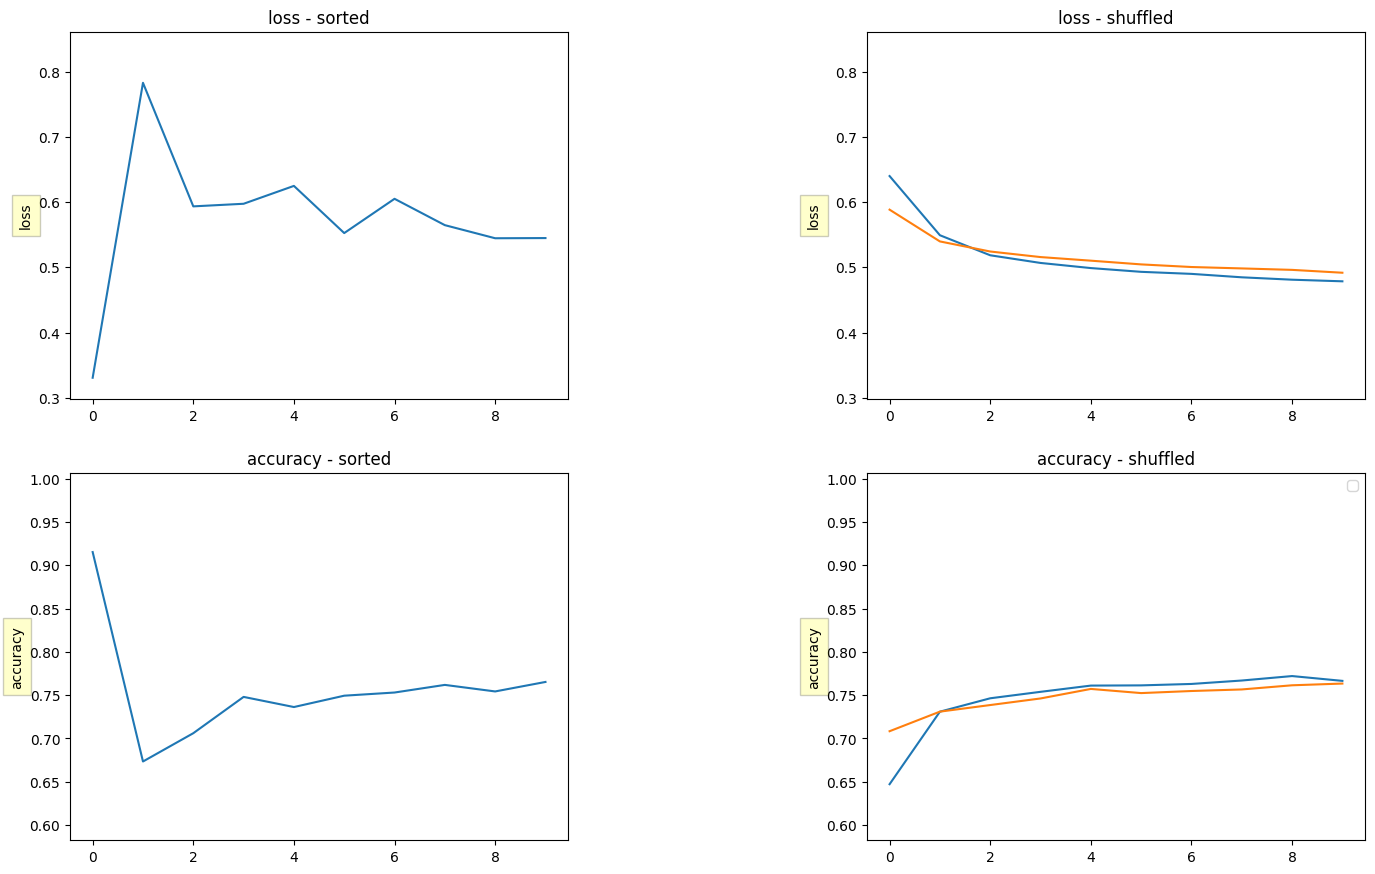

In [112]:
fig, axs = plt.subplots(2, 2)
fig.subplots_adjust(left=0.2, wspace=0.6)
make_plot(axs,
          dan_sorted_history,
          dan_shuffled_history,
          model_1_name='sorted',
         model_2_name='shuffled')

fig.align_ylabels(axs[:, 1])
fig.set_size_inches(18.5, 10.5)
plt.legend()
plt.show()

### 1.3 Approaches for Training of Embeddings

Rerun the DAN Model in 3 separate configurations:


a.   embedding_initializer = 'word2vec' and retrain_embeddings=False

b.   embedding_initializer = 'word2vec' and retrain_embeddings=True

c.   embedding_initializer = 'uniform' and retrain_embeddings=True


**NOTE:** Train the model with static embeddings for 10 epochs and the ones with trainable embeddings for 3 epochs each. Make sure you are using the original training data we created and not the sorted data.

What do you observe about the effects of initializing and retraining the embedding matrix?



**QUESTION:**

1.3.a (3 pts) First, what is the final validation accuracy that you just observed for the static model initialized with the word2vec after 10 epochs?

In [115]:
#1.3.a
### YOUR CODE HERE
def embedding_ablation(retrain_embeddings, embedding_initializer):
      return create_dan_model(retrain_embeddings=retrain_embeddings,
                     max_sequence_length=MAX_SEQUENCE_LENGTH,
                     hidden_dim=100,
                     dropout=0.3,
                     embedding_initializer=embedding_initializer,
                     learning_rate=0.001)

dan_model_static = embedding_ablation(retrain_embeddings=False, embedding_initializer='word2vec')

dan_static_history = dan_model_static.fit(
    train_input_ids,
    train_labels,
    validation_data=(test_input_ids, test_input_labels),
    batch_size=32,
    epochs=10,
    shuffle=True
)


### END YOUR CODE

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.6481 - loss: 0.6465 - val_accuracy: 0.7006 - val_loss: 0.5991
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7276 - loss: 0.5570 - val_accuracy: 0.7312 - val_loss: 0.5461
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7461 - loss: 0.5224 - val_accuracy: 0.7414 - val_loss: 0.5325
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7513 - loss: 0.5097 - val_accuracy: 0.7438 - val_loss: 0.5181
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7553 - loss: 0.5017 - val_accuracy: 0.7528 - val_loss: 0.5121
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7606 - loss: 0.4952 - val_accuracy: 0.7550 - val_loss: 0.5065
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7631 - loss: 0.4902 - val_accuracy: 0.7518 - val_loss: 0.5045
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7655 - loss: 0.4865 - val_accuracy: 0

In [118]:
### --- Put your answer for 1.3.a. in Gradescope Q.6. Do not enter your answer here. --- ###
print(f"{dan_static_history.history["val_accuracy"][-1]:.5f}")

0.75660


**QUESTION:**


1.3.b (3 pts) What is the final validation accuracy that you observed for the model where you initialized with word2vec vectors but allow them to retrain for 3 epochs?



In [116]:
#1.3.b
### YOUR CODE HERE
dan_model_retrain = embedding_ablation(retrain_embeddings=True, embedding_initializer='word2vec')

dan_retrain_history = dan_model_retrain.fit(
    train_input_ids,
    train_labels,
    validation_data=(test_input_ids, test_input_labels),
    batch_size=32,
    epochs=3,
    shuffle=True
)


### END YOUR CODE

Epoch 1/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.7495 - loss: 0.5025 - val_accuracy: 0.7902 - val_loss: 0.4375
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8668 - loss: 0.3209 - val_accuracy: 0.7876 - val_loss: 0.4667
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9130 - loss: 0.2324 - val_accuracy: 0.7768 - val_loss: 0.5298


In [119]:
### --- Put your answer for 1.3.b in Gradescope Q.7. Do not enter your answer here. --- ###
print(f"{dan_retrain_history.history["val_accuracy"][-1]:.5f}")

0.77680


**QUESTION:**

1.3.c (3 pts) What is the final validation accuracy that you observed for the model where you initialized randomly and then trained?




In [117]:
#1.3.c
### YOUR CODE HERE

dan_model_uniform = embedding_ablation(retrain_embeddings=True, embedding_initializer='uniform')

dan_uniform_history = dan_model_uniform.fit(
    train_input_ids,
    train_labels,
    validation_data=(test_input_ids, test_input_labels),
    batch_size=32,
    epochs=3,
    shuffle=True
)


### END YOUR CODE

Epoch 1/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.7527 - loss: 0.5041 - val_accuracy: 0.7938 - val_loss: 0.4464
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8686 - loss: 0.3185 - val_accuracy: 0.7882 - val_loss: 0.4622
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9111 - loss: 0.2306 - val_accuracy: 0.7622 - val_loss: 0.5781


In [120]:
### --- Put your answer for 1.3.c in Gradescope Q.8. Do not enter your answer here. --- ###
print(f"{dan_uniform_history.history["val_accuracy"][-1]:.5f}")

0.76220


## Section 2: Text Classification with Convolutional Neural Networks

**Description:** This assignment covers various neural network architectures and components, largely used in the context of classification. You will compare Deep Averaging Networks, Convolutional Neural Networks, and BERT-based models. In section two, you should be able to develop an intuition for:


*   The effects of fine-tuning word vectors and over fitting the model
*   How various hyperparameters can help or hurt overfitting


The assignment notebook closely follows the lesson notebooks. We will again use the IMDB dataset and will leverage some of the models, or part of the code, for our current investigation.

This notebook uses the Keras 3 functional API.  Make sure the correct versions get loaded.




We can continue to use the data set that we set up in Section 1.  Let's confirm its still loaded in memory.


In [95]:
train_examples[:4]

<tf.Tensor: shape=(4,), dtype=string, numpy=
array([b"This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it.",
       b'I have been known to fall asleep during films, but this is usually due to a combination of things including, really tired, being warm and comfortable on the sette and having just eaten a lot. However on this occasion I fell a

In [96]:
train_labels[:4]

<tf.Tensor: shape=(4,), dtype=int64, numpy=array([0, 0, 0, 1])>

Yup... looks right. Of course we will need to take care of the encoding again.

#### 2.0 Data Preparation

For the models we will use, we need to define a new maximum sequence length (max number of tokens per movie review that we'll feed into our model). We'll cut off any tokens longer than that, and we'll pad shorter movie reviews with zeros at the end.

In [97]:
MAX_SEQUENCE_LENGTH = 128

Next, we define a simple function that converts the tokens of each movie review into their word2vec vocabulary index values.   

In [98]:
def docs_to_vocab_ids(tokenized_texts_list):
    """
    converting a list of strings to a list of lists of word ids
    """
    texts_vocab_ids = []
    for i, token_list in enumerate(tokenized_texts_list):

        # Get the vocab id for each token in this doc ([UNK] if not in vocab)
        vocab_ids = []
        for token in list(token_list.numpy()):
            decoded = token.decode('utf-8', errors='ignore')
            if decoded in vocab_dict:
                vocab_ids.append(vocab_dict[decoded])
            else:
                vocab_ids.append(vocab_dict['[UNK]'])

        # Truncate text to max length, add padding up to max length
        vocab_ids = vocab_ids[:MAX_SEQUENCE_LENGTH]
        n_padding = (MAX_SEQUENCE_LENGTH - len(vocab_ids))
        # For simplicity in this model, we'll just pad with uknown tokens
        vocab_ids += [vocab_dict['[UNK]']] * n_padding

        # Add this example to the list of converted docs
        texts_vocab_ids.append(vocab_ids)

        if i % 5000 == 0:
            print('Examples processed: ', i)

    print('Total examples: ', i)

    return np.array(texts_vocab_ids)

Now we can create training and test data that can be fed into the models of interest.

In [99]:
train_input = docs_to_vocab_ids(train_tokens)
test_input = docs_to_vocab_ids(test_tokens)

train_labels = np.array(train_labels)
test_labels = np.array(test_labels)

Examples processed:  0
Examples processed:  5000
Examples processed:  10000
Examples processed:  15000
Total examples:  19999
Examples processed:  0
Total examples:  4999


Let's convince ourselves that the data looks correct.  We expect the train data to be an array of integer ids and the labels to be an array of zeroes and ones (since we are learning a binary classifier).

In [100]:
train_input[:2]

array([[21531, 25272, 12291,  7427, 37254, 43981,  6891, 12917, 38232,
        16915, 12929, 16182, 43981, 20526, 23487, 43981, 23807, 42958,
        35058, 43981, 19123, 35029, 41270, 29275, 12917, 32597, 20659,
          638, 16915, 43981,   174, 32597, 35058, 39971,  2326,  3636,
        22434, 35029, 43981, 33922, 43981, 21531, 34710, 16908, 12291,
        36880, 28137,  5376, 28038, 43981, 15402, 29155, 18063, 24951,
        17433, 17595,  8856, 14193, 43981, 43248, 17433,  6290, 32597,
         9001, 11511, 43981, 21807, 39168, 43981, 16856, 43981, 43981,
        23245, 43981,  8889,  1331, 43981, 25272, 31976, 19123, 43981,
        18063, 36309, 24099, 16915, 43981, 34710, 36633, 25272, 20413,
        43981, 33458, 14926, 43981, 12139, 12289, 39617, 36633,  9483,
        42958,  5589,  8092, 43981, 34516, 43981,  8092, 16182, 43981,
        39933, 43981, 12139,  2326, 32781, 32467,  7046, 43981, 43981,
        43981, 43981, 43981, 43981, 43981, 43981, 43981, 43981, 43981,
      

In [101]:
train_labels[:4]

array([0, 0, 0, 1])

[link text](https://)
<a id = 'modelCNN'></a>
#### 2.1 CNN Model

Next let's build a CNN model. We'll also wrap the model building code in a function that takes some hyperparameters, so that we can adjust things like number of filters and filter sizes later.

In [102]:
def build_cnn_model(num_filters, kernel_sizes, dense_layer_dims, dropout_rate, embeddings_trainable=False):
    cnn_input_layer = keras.layers.Input(shape=(MAX_SEQUENCE_LENGTH,), dtype='int64')
    cnn_embedding_layer = Embedding(embedding_matrix.shape[0],
                                    embedding_matrix.shape[1],
                                    embeddings_initializer=keras.initializers.Constant(embedding_matrix),
                                    input_length=MAX_SEQUENCE_LENGTH,
                                    trainable=embeddings_trainable)
    cnn_embeddings = cnn_embedding_layer(cnn_input_layer)

    conv_layers_for_all_kernel_sizes = []
    for kernel_size, filters in zip(kernel_sizes, num_filters):
        conv_layer = keras.layers.Conv1D(filters=filters, kernel_size=kernel_size, activation='relu')(cnn_embeddings)
        conv_layer = keras.layers.GlobalMaxPooling1D()(conv_layer)
        conv_layers_for_all_kernel_sizes.append(conv_layer)

    conv_output = keras.layers.concatenate(conv_layers_for_all_kernel_sizes, axis=1)
    last_hidden_output = keras.layers.Dropout(rate=dropout_rate)(conv_output)

    for dense_layer_dim in dense_layer_dims:
        last_hidden_output = keras.layers.Dense(dense_layer_dim, activation='relu')(last_hidden_output)

    cnn_prediction = keras.layers.Dense(1, activation='sigmoid')(last_hidden_output)

    cnn_model = keras.Model(inputs=cnn_input_layer, outputs=cnn_prediction)
    cnn_model.compile(optimizer='adam',
                      loss='binary_crossentropy',  # From information theory notebooks.
                      metrics=['accuracy'])
    return cnn_model

In [103]:
# Now specify model hyperparameters and call the function to create a CNN model

num_filters = [100, 100, 50, 25]
kernel_sizes = [3, 4, 5, 10]
dense_layer_dims = [100, 50]
dropout_rate = 0.5

cnn_model = build_cnn_model(num_filters, kernel_sizes, dense_layer_dims, dropout_rate)

In [104]:
cnn_model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_6         │ (None, 128, 300)  │ 13,194,600 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 126, 100)  │     90,100 │ embedding_6[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 125, 100)  │    120,100 │ embedding_6[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 124, 50)   │     75,050 │ embedding_6[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 119, 25)   │     75,025 │ embedding_6[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 100)       │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 100)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 50)        │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 25)        │          0 │ conv1d_3[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 275)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 275)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 100)       │     27,600 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 50)        │      5,050 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         51 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 13,587,576 (51.83 MB)

 Trainable params: 392,976 (1.50 MB)

 Non-trainable params: 13,194,600 (50.33 MB)

The keras plot utility shows this probably a bit nicer:

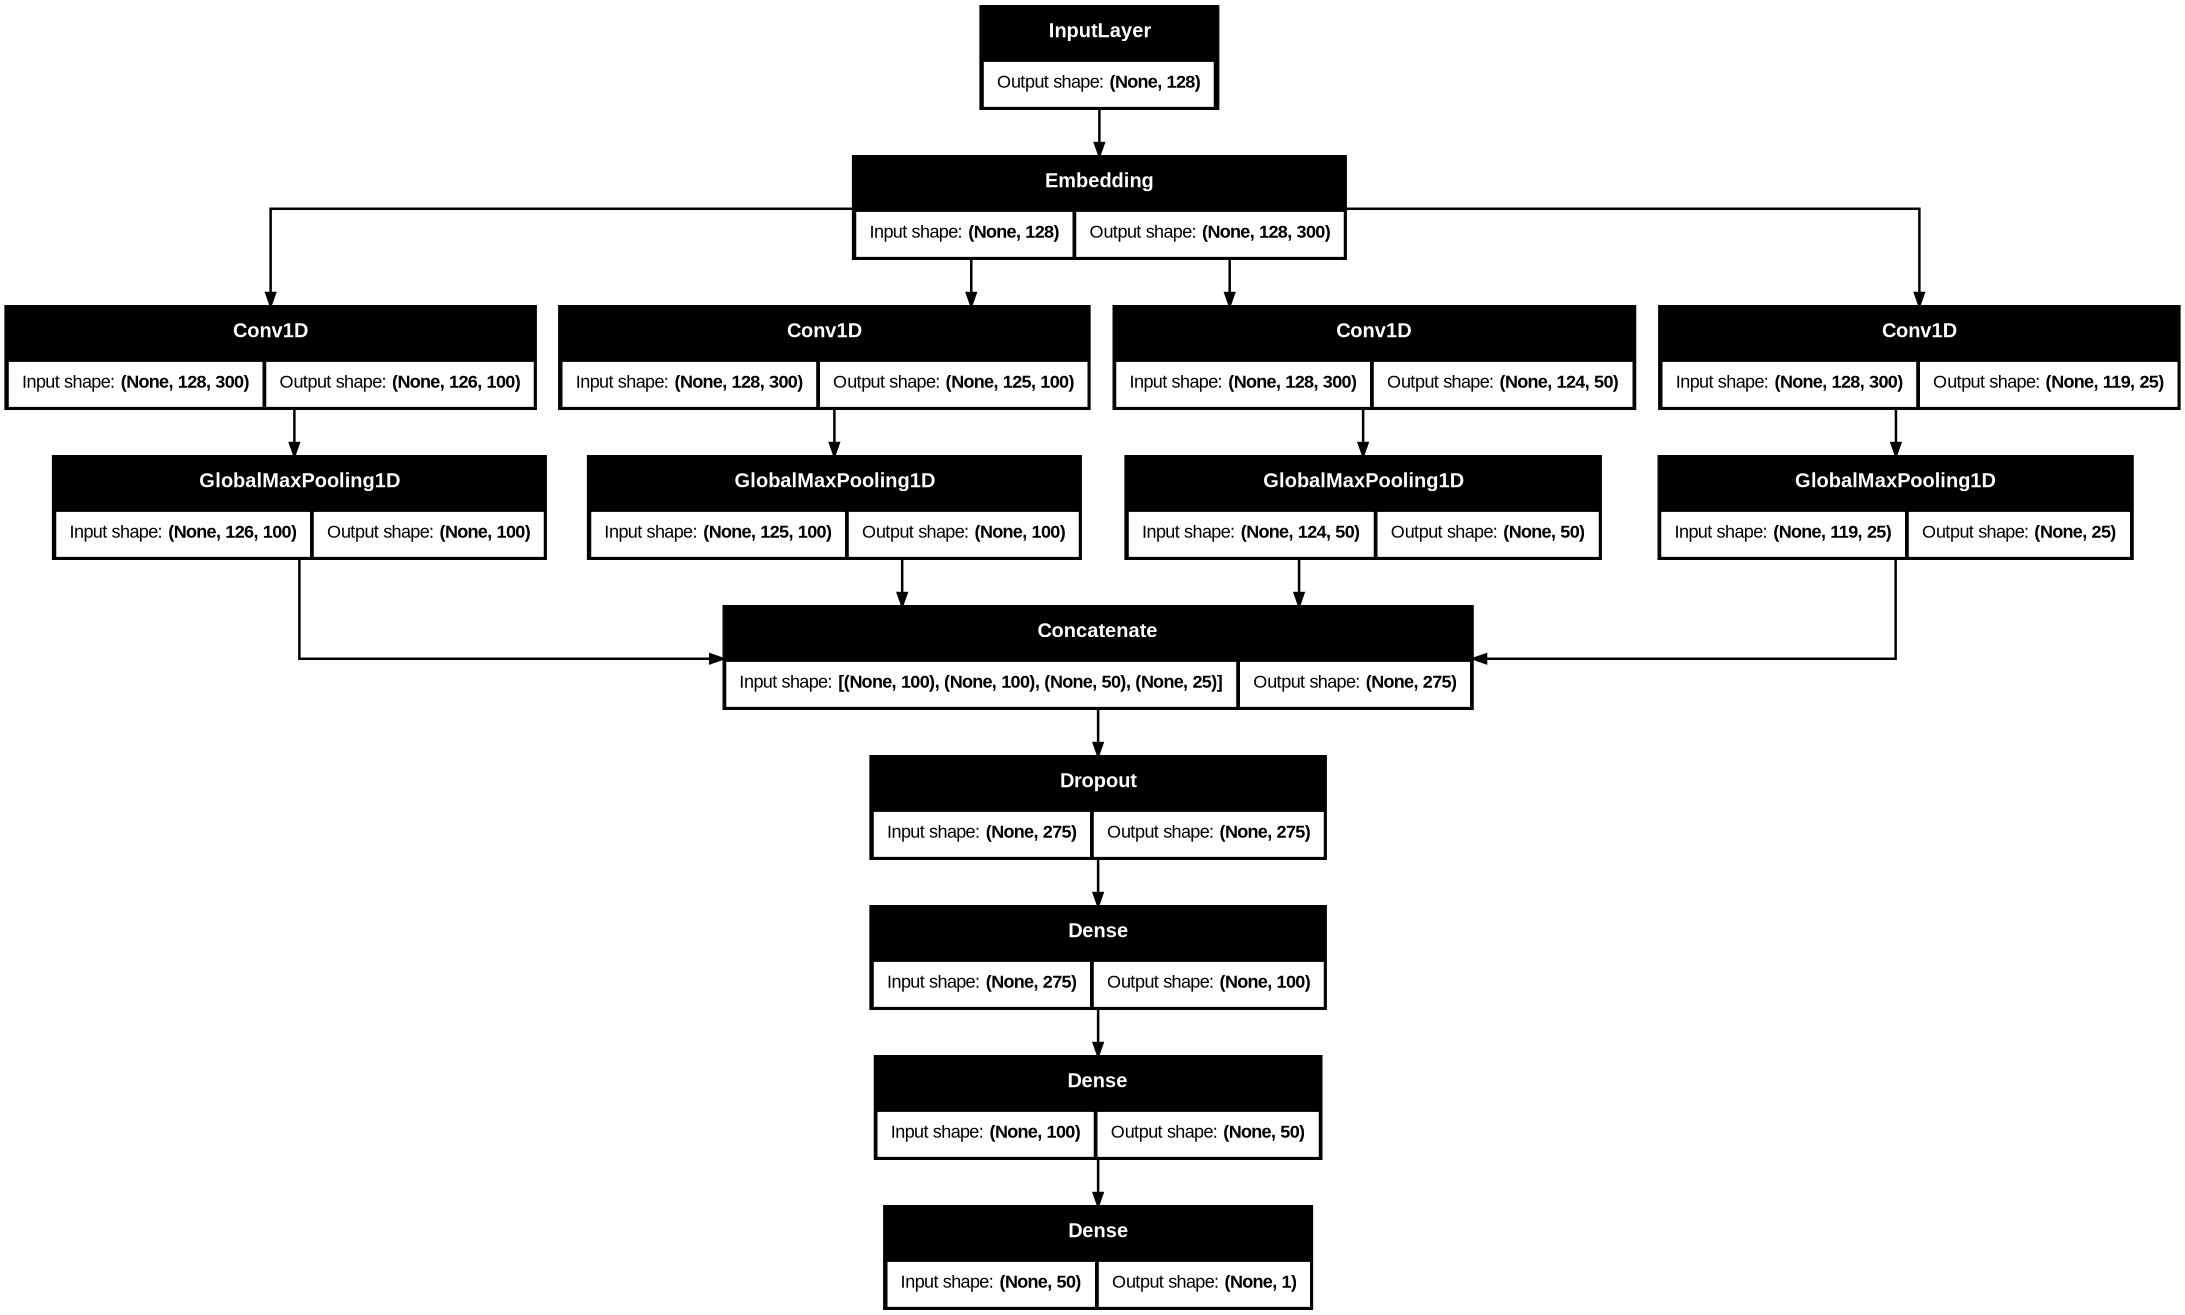

In [105]:
keras.utils.plot_model(cnn_model, show_shapes=True, dpi=90)

Now let's train our CNN and see if it can learn without overfitting or underfitting.

In [106]:
cnn_history = cnn_model.fit(train_input,
                            train_labels,
                            validation_data=(test_input, test_labels),
                            batch_size=32,
                            epochs=5
                            )

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 159s 253ms/step - accuracy: 0.6960 - loss: 0.5549 - val_accuracy: 0.7982 - val_loss: 0.4435
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 158s 252ms/step - accuracy: 0.8033 - loss: 0.4255 - val_accuracy: 0.8170 - val_loss: 0.4043
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 144s 230ms/step - accuracy: 0.8342 - loss: 0.3746 - val_accuracy: 0.8172 - val_loss: 0.3983
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 142s 227ms/step - accuracy: 0.8617 - loss: 0.3271 - val_accuracy: 0.8116 - val_loss: 0.4086
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 141s 226ms/step - accuracy: 0.8824 - loss: 0.2781 - val_accuracy: 0.8226 - val_loss: 0.4093


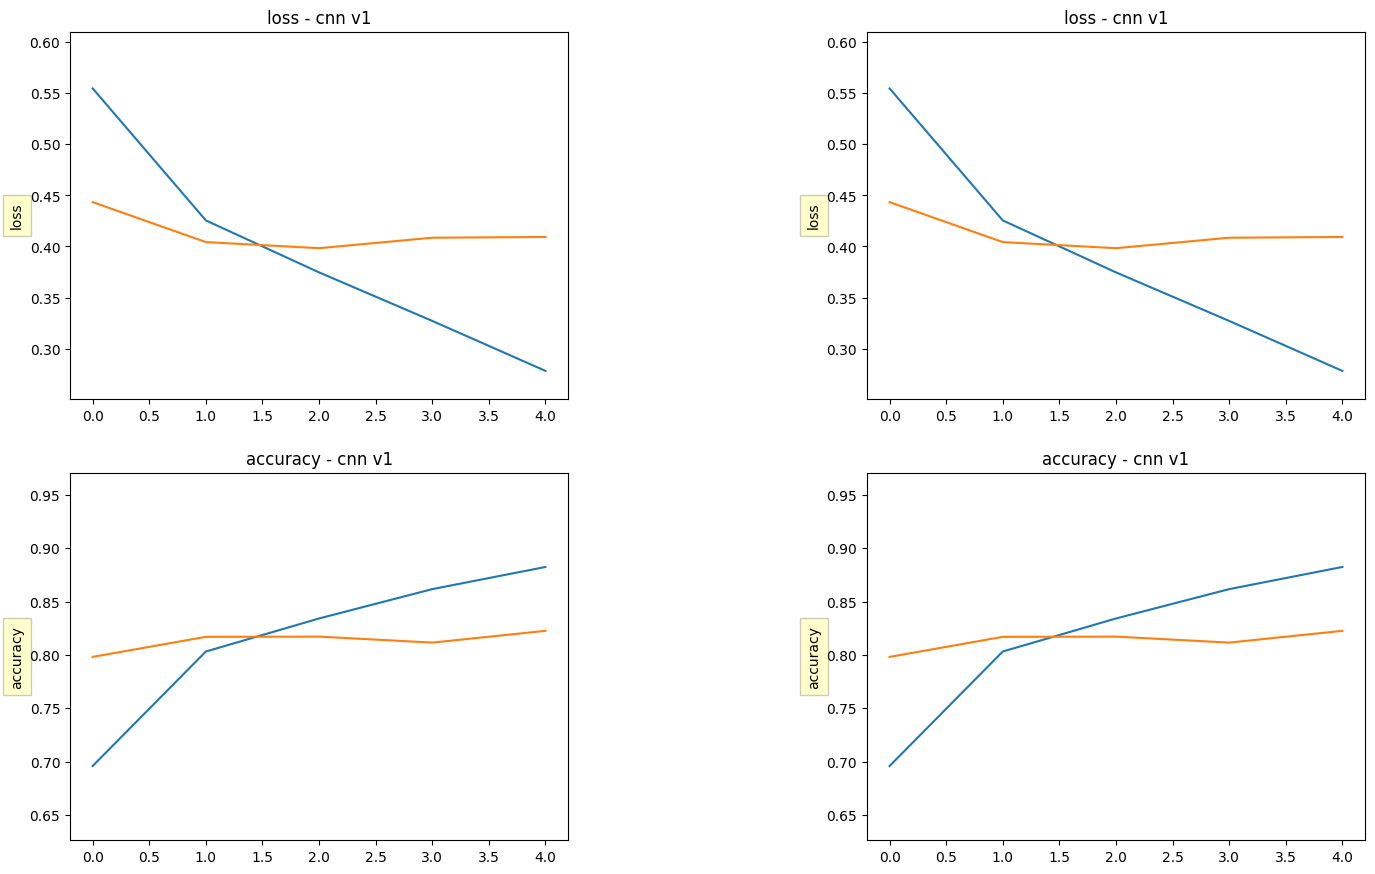

In [107]:
# Do the plots change how you'd expect?
# Did the runtime change (in the cells above)?

fig, axs = plt.subplots(2, 2)
fig.subplots_adjust(left=0.2, wspace=0.6)
make_plot(axs,
          cnn_history,
          cnn_history,
          model_1_name='cnn v1',
          model_2_name='cnn v1')

fig.align_ylabels(axs[:, 1])
fig.set_size_inches(18.5, 10.5)
plt.show()

[Return to Top](#returnToTop)  
<a id = 'cnnExercise'></a>
#### 2.2. CNN Training Exercise

A. The CNN model above is overfitting.  You can tell this because the training loss keeps going down while the validation loss is increasing. Can you make the CNN model overfit less? What parameter(s) might you change to make this model less likely to overfit? How good (or bad) can you make it get?

> Hint: think about all of the options you can vary, including:
* add/remove more hidden layers
* vary dropout rates and dimensions
* enable/disable retraining of embedding matrix
* change number of filters
* change kernel sizes of filters
* change the batch size
>
> For the option(s) you choose, do you think it will make the model more or less likely to overfit? Try it, does it work the way you expect?

Here is an example of the loss curve for a model that is extremely overfit:

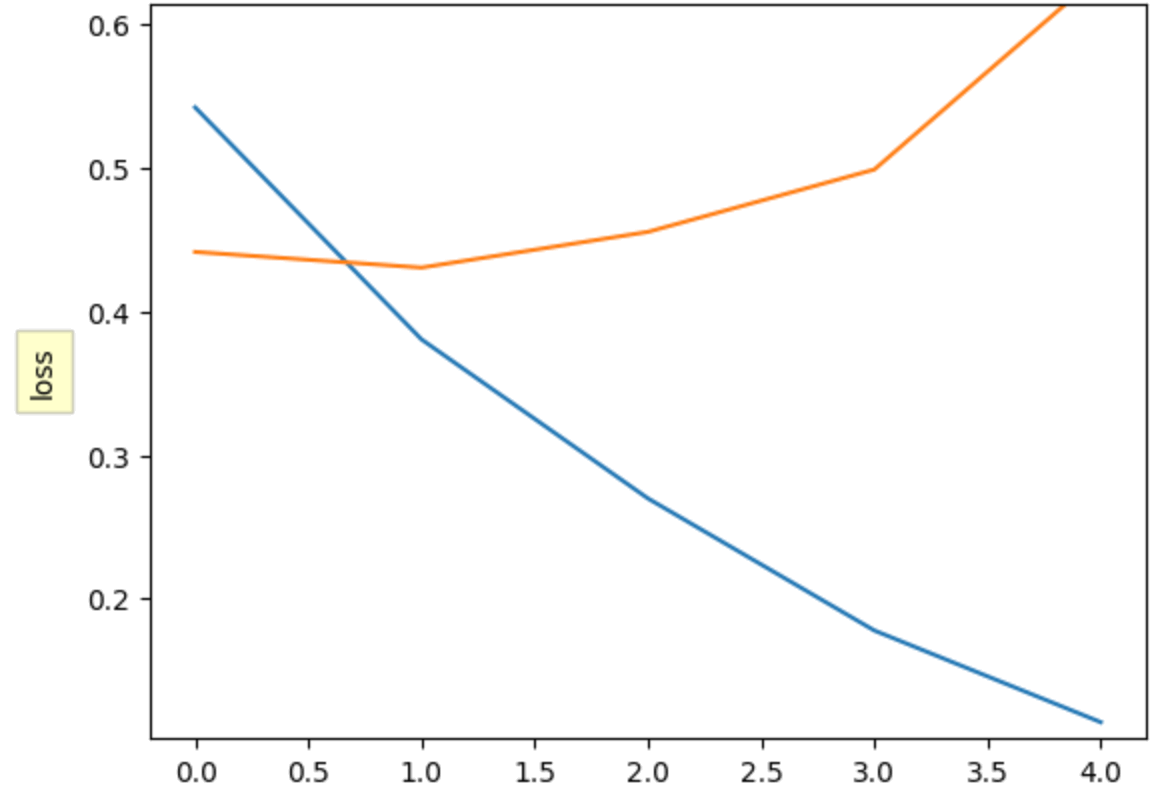

and here is an example of the loss curve where the model is converging and not overfitting:

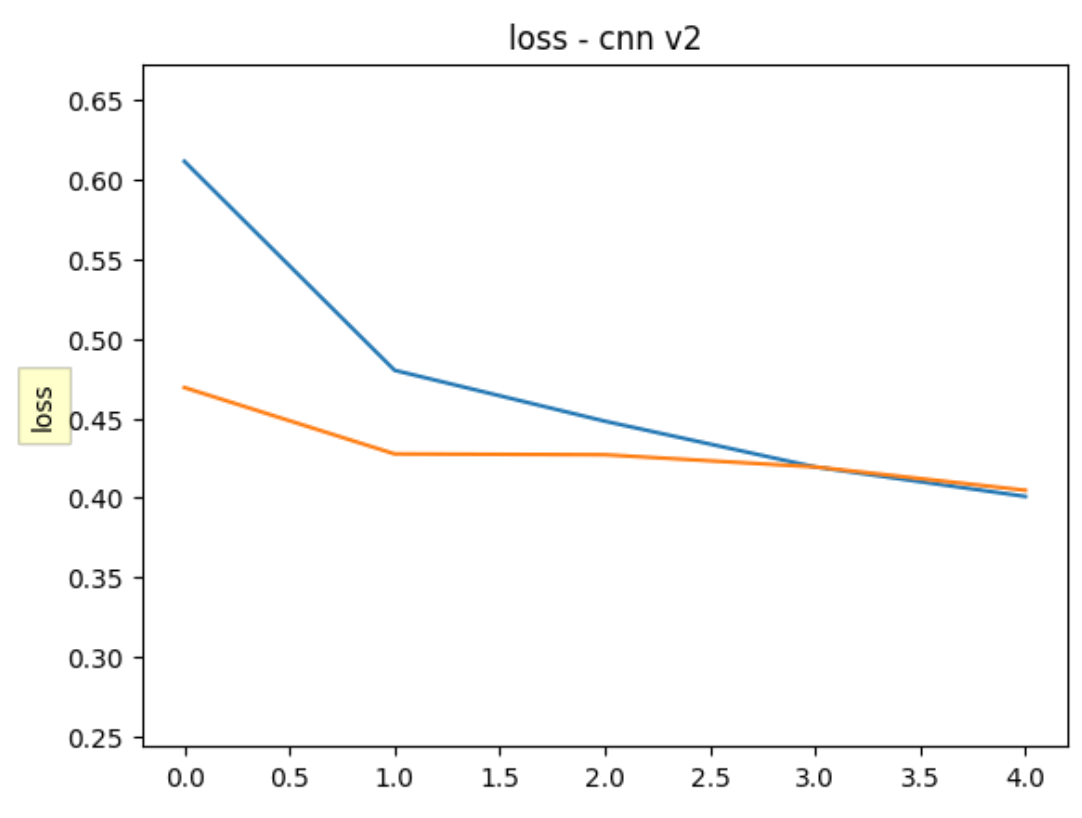


Your task is to fix the CNN model so that it is no longer overfit when you train it.  You should modify the specified hyperparameters until the model no longer overfits. We define your goal as a case where after each epoch, the loss and val_loss value is lower than the epoch before.  This will be reflected in the shape of the loss curves as shown above.  

In [108]:
# CNN model hyperparameters: Change these

### YOUR CODE HERE

#num_filters = []
#kernel_sizes = []
#dense__layer_dims= []
#dropout_rate = []
#embeddings_trainable =
#batch_size =


### END YOUR CODE

cnn_model2 = build_cnn_model(num_filters, kernel_sizes, dense_layer_dims,
                            dropout_rate, embeddings_trainable)

cnn_history2 = cnn_model2.fit(train_input,
                              train_labels,
                              validation_data=(test_input, test_labels),
                              batch_size=batch_size,
                              epochs=5
                              )

NameError: name 'embeddings_trainable' is not defined

In [ ]:
# Do the plots change how you'd expect?
# Did the runtime change (in the cells above)?

fig, axs = plt.subplots(2, 2)
fig.subplots_adjust(left=0.2, wspace=0.6)
make_plot(axs,
          cnn_history,
          cnn_history2,
          model_1_name='cnn v1',
          model_2_name='cnn v2')

fig.align_ylabels(axs[:, 1])
fig.set_size_inches(18.5, 10.5)
plt.show()

 **QUESTION:**

2.1.a (2 pts)
What is the val_loss value you have after the 1st epoch of training?

In [ ]:
### --- Put your answer for 2.1.a in Gradescope Q.9. Do not enter your answer here. --- ###

**QUESTION:**

2.1.b (2pts)
What is the val_loss value you have after the 2nd epoch of training?

In [ ]:
### --- Put your answer for 2.1.b in Gradescope Q.10. Do not enter your answer here. --- ###

 **QUESTION:**

2.1.c (2 pts)
What is the val_loss value you have after the 3rd epoch of training?

In [ ]:
### --- Put your answer for 2.1.c in Gradescope Q.11. Do not enter your answer here. --- ###

 **QUESTION:**

2.1.d (2 pts)
What is the val_loss value you have after the 4th epoch of training?

In [ ]:
### --- Put your answer 2.1.d in Gradescope Q.12. Do not enter your answer here. --- ###

 **QUESTION:**

2.1.e (2 pts)
What is the val_loss value you have after the 5th and final epoch of training.

In [ ]:
### --- Put your answer for 2.1.e in Gradescope Q.13. Do not enter your answer here. --- ###

 **QUESTION:**

2.1.f (2 pts)
What values did you use for num_filters = [] to stop the overfitting?

In [ ]:
### --- Put your answer 2.1.f in Gradescope Q.14. Do not enter your answer here. --- ###

 **QUESTION:**

2.1.g (2 pts)
What values did you use for kernel_sizes = [] to stop the overfitting?

In [ ]:
### --- Put your answer 2.1.g in Gradescope Q.15. Do not enter your answer here. --- ###

**QUESTION:**

2.1.h (2 pts)
What values did you use for dense__layer_dims= [] to stop the overfitting?

In [ ]:
### --- Put your answer in Gradescope Q.16. Do not enter your answer here. --- ###

 **QUESTION:**

2.1.i (2 pts)
What value did you use for dropout_rate = [] to stop the overfitting?

In [ ]:
### --- Put your answer in Gradescope Q.17. Do not enter your answer here. --- ###

 **QUESTION:**

2.1.j (2 pts)
What value did you use for embeddings_trainable = to stop the overfitting?

In [ ]:
### --- Put your answer in Gradescope Q.18. Do not enter your answer here. --- ###

 **QUESTION:**

2.1.k (2 pts)
What value did you use for batch_size = to stop the overfitting?

In [ ]:
### --- Put your answer in Gradescope Q.19. Do not enter your answer here. --- ###

You're done with this portion.  Continue on to the next section.

## Section 3: Text Classification with BERT

**Description:** This assignment notebook builds on the material from the
[lesson 4 notebook](https://drive.google.com/file/d/1BJIaAC36aoxERHoYuWTA1XlBnd6F-0Xp/view?usp=sharing), in which we fine-tuned a BERT model for the IMDB movie reviews sentiment classification task. In that notebook, we used the bert-base-cased model and applied traditional fine-tuning, with a brief class exercise at the end to try unfreezing different numbers of layers. In this assignment, we'll start with that exercise, and ask you to explore unfreezing more specific layers yourself. Then you'll search for and try different pre-trained BERT-style models.

This section should be run on a Google Colab leveraging a GPU. By default, when you open the notebook in Colab it will try to use a GPU. Please note that the GPU is required for Sections 3.2 and 3.3 but not for Section 3.1.
Since colab is providing free access to a GPU they place constraints on that access.  Therefore you might want to turn off the GPU access (Edit -> Notebook Settings) until you get to section 3.3.  Total runtime of the entire section 3 (with solutions and a Colab GPU) should be about 1h with the majority of that time being in Section 3.3. If Colab tells you that you have reached your GPU limit, wait up to 24 hours and you should be able to access a GPU again.


The structure for section 3 is as follows:


    3.0. Setup
  
        3.0.1 Libraries and Helper Functions

        3.0.2 Data Acquisition

        3.0.3. Data Preparation


    3.1. Classification with BERT

        3.1.1 BERT Basics

        3.1.2 Testing Pre-trained BERT models  

        3.1.3 Unfreezing layers in training


**INSTRUCTIONS:**:

* Questions are always indicated as **QUESTION**, so you can search for this string to make sure you answered all of the questions. You are expected to fill out, run, and submit this notebook, as well as to answer the questions in the **answers** file as you did in a1.  Please do **not** remove the output from your notebooks when you submit them as we'll look at the output as well as your code for grading purposes.  We cannot award points if the output cells are empty.

* **### YOUR CODE HERE** indicates that you are supposed to write code.

* If you want to, you can run all of the cells in section 0 in bulk. This is setup work and no questions are in there. At the end of section 0 we will state all of the relevant variables that were defined and created in section 1.

* Finally, unless otherwise indicated your validation accuracy will be 0.65 or higher if you have correctly implemented the model.



### 3.0. Setup

**YOU MUST RESTART THE NOTEBOOK**

#### 3.0.0. Libraries and Helper Functions

This notebook requires the Hugging Face datasets and other prerequisites that Colab must download.  

In [ ]:
!pip install -U -q transformers
!pip install -U -q torchinfo
!pip install -U -q torchdata
!pip install -U -q datasets
!pip install -U -q huggingface-hub
!pip install -U -q evaluate

Now we are ready to do the imports.

#### 3.0.1 Imports

In [ ]:
import numpy as np
import torch

import transformers
import evaluate

from datasets import load_dataset
from torchinfo import summary

from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer

#### 3.0.2 Data Acquisition


We will use the IMDB dataset delivered as part of the Hugging Face datasets library, and split into training and test sets. For expedience, we will limit ourselves in terms of train and test examples.

In [ ]:
imdb_dataset = load_dataset("stanfordnlp/imdb")

imdb_train_dataset = imdb_dataset['train'].shuffle()
imdb_dev_dataset = imdb_dataset['test'].shuffle().select(range(5000))

It is always highly recommended to look at the data. What do the records look like? Are they clean or do they contain a lot of cruft (potential noise)?

In [ ]:
imdb_train_dataset

In [ ]:
for i in range(4):
  print(imdb_train_dataset['text'][i])
  print(imdb_train_dataset['label'][i])
  print()

In [ ]:
imdb_train_dataset.features['label'].names

For convenience, in this assignment we will define a sequence length and truncate all records at that length. For records that are shorter than our defined sequence length we will add padding characters to insure that our input shapes are consistent across all records.

In [ ]:
MAX_SEQUENCE_LENGTH = 100

#### 3.0.3. Data Preparation


We will need to tokenize the text into vocab_ids to pass into a BERT model. To do so, we'll need to use the specific tokenizer that goes with the model we're using. In this notebook, we will try several different BERT-style models. Let's
first write a function that will take the text from our dataset and a tokenizer, and encode the text using that tokenizer. Then we'll apply the function to our dataset for each tokenizer and model.

In [ ]:
def preprocess_imdb(data, tokenizer):
    review_text = data['text']

    encoded = tokenizer(
            review_text,
            max_length=MAX_SEQUENCE_LENGTH,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_token_type_ids=True,
            return_tensors="pt"
        )

    return encoded


### 3.1. BERT-based Classification Models

Now we turn to classification with BERT. We will perform classifications with various models that are based on pre-trained BERT models.  If you turn off GPU access while coding and debugging the setup steps, make sure you change the Notebook settings so you can access a GPU when you're ready to train the models.


#### 3.1.1. Basics

Let us first explore some basics of BERT. We'll start by loading the first pretrained BERT model and tokenizer that we'll use ('bert-base-cased').

To explore just the pre-trained portion of the model, we'll use the AutoModel class (equivalent to BertModel, but works for any architecture including BERT). This class gives us the pre-trained model layers up until the last hidden layer (but not any output layer).

In [ ]:
bert_tokenizer = AutoTokenizer.from_pretrained('bert-base-cased')
bert_model = AutoModel.from_pretrained('bert-base-cased')

Let's look at a couple of example sentences:

In [ ]:
test_input = ['this bank is closed on Sunday', 'the steepest bank of the river is dangerous']

Apply the BERT tokenizer to tokenize them:

In [ ]:
tokenized_input = bert_tokenizer(test_input,
                                 max_length=12,
                                 truncation=True,
                                 padding='max_length',
                                 return_tensors='pt')

tokenized_input

 **QUESTION:**

 3.1.a  (1 pt) Why do the attention_masks have 4 and 1 zeros, respectively?  

  -  For the first example the last four tokens belong to a different segment. For the second one it is only the last token.

  -  For the first example 4 positions are padded while for the second one it is only one.

In [ ]:
### YOUR CODE HERE

# bert_output = ...


### END YOUR CODE

In [ ]:
### --- Put your answer for 3.1.a in Gradescope Q.20. Do not enter your answer here. --- ###

 **QUESTION:**

 3.1.b (1 pt) How many outputs are there?

In [ ]:
### YOUR CODE HERE

#b. -> print it out



### END YOUR CODE

In [ ]:
### --- Put your answer for 3.1.b in Gradescope Q.21. Do not enter your answer here. --- ###

**QUESTION:**

3.1.c. (1 pt) Which output do we need to use to get token-level embeddings?

* the first

* the second


In [ ]:
### --- Put your answer for 3.1.c in Gradescope Q.22. Do not enter your answer here. --- ###

**QUESTION:**

 3.1.d. (2 pts) In the tokenized input, which input_id number (i.e. the vocabulary id) corresponds to 'bank' in the two sentences? ('bert_tokenizer.tokenize()' may come in handy.. and don't forget the CLS token! )


In [ ]:
### YOUR CODE HERE

#d/e. -> Look at tokens generated by the bert tokenizer for the first example


### END YOUR CODE

In [ ]:
### --- Put your answer for 3.1.d in Gradescope Q.23. Do not enter your answer here. --- ###

**QUESTION:**

 3.1.e (2 pts) In the array of tokens, which position index number corresponds to 'bank' in the first sentence? ('bert_tokenizer.tokenize()' may come in handy.. and don't forget the CLS token! )

In [ ]:
### --- Put your answer for 3.1.e in Gradescope Q.24. Do not enter your answer here. --- ###

**QUESTION:**

3.1.f (2 pts) Which array position index number corresponds to 'bank' in the second sentence?

In [ ]:
### YOUR CODE HERE

#f. -> Look at tokenization for the second example



### END YOUR CODE

In [ ]:
### --- Put your answer for 3.1.f in Gradescope Q.25. Do not enter your answer here. --- ###

**QUESTION:**

 3.1.g (3 pts) What is the cosine similarity between the BERT embeddings for the two occurrences of 'bank' in the two sentences?

In [ ]:
### YOUR CODE HERE

#g.  -> get the vectors and calculate cosine similarity between the two 'bank' BERT embedddings



### END YOUR CODE

In [ ]:
### --- Put your answer for 3.1.g in Gradescope Q.26. Do not enter your answer here. --- ###

**QUESTION:**

3.1.h (3 pts) How does this relate to the cosine similarity of 'this' (in sentence 1) and the first 'the' (in sentence 2). Compute their cosine similarity.


In [ ]:
### YOUR CODE HERE

#h.  -> get the vectors and calculate cosine similarity


### END YOUR CODE

In [ ]:
### --- Put your answer for 3.1.h in Gradescope Q.27. Do not enter your answer here. --- ###

### 3.2. Testing Different Pre-Trained BERT Models

In the live session we discussed classification with the `bert-base-cased` model, using the Huggingface class BertForSequenceClassification, which comes with a new output layer for our task that we need to train on our dataset.

We're going to try different pre-trained models now. Like in the lesson 4 notebook, we'll want to fine-tune each model on our IMDB reviews dataset and compare them with a metric like the validation accuracy. We'll use the model class AutoModelForSequenceClassification, which is equivalent to BertForSequenceClassification, but works for other similar architectures too.

Let's write the code we'll need as a function that takes the model and tokenizer as arguments, along with the raw train and dev data. The function will need to tokenize the inputs using the provided tokenizer, so that we can repeat the same code for different pre-trained models. Then the function should create the training args and trainer class, and call trainer.train().

The other hyperparameters you'll need are provided in the function definition, including batch_size and num_epochs. You should use the default values provided for those. Use the function provided below for compute_metrics.

For now, keep all layers of the pre-trained models you load unfrozen.

In [ ]:
metric = evaluate.load('accuracy')

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=1)
    return metric.compute(predictions=predictions, references=labels)

In [ ]:
def fine_tune_classification_model(classification_model,
                                   tokenizer,
                                   train_data,
                                   dev_data,
                                   batch_size = 16,
                                   num_epochs = 2):
    """
    Preprocess the data using the given tokenizer (we've give you the code for that part).
    Create the training arguments and trainer for the given model and data (write your code for that).
    Then train it.
    """

    preprocessed_train_data = train_data.map(preprocess_imdb, batched=True, fn_kwargs={'tokenizer': tokenizer})
    preprocessed_dev_data = dev_data.map(preprocess_imdb, batched=True, fn_kwargs={'tokenizer': tokenizer})

    ### YOUR CODE HERE


    ### END YOUR CODE

    trainer.train()

Let's try BERT-base-case first, the same model that was used in the lesson 4 notebook.

In [ ]:
"""
Show the output from training BERT-base-cased on the IMDB movie reviews dataset.
"""

model_checkpoint_name = "bert-base-cased"
bert_tokenizer = AutoTokenizer.from_pretrained(model_checkpoint_name)
bert_classification_model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint_name)

fine_tune_classification_model(bert_classification_model, bert_tokenizer, imdb_train_dataset, imdb_dev_dataset)

Often, one of the first choices you have is what pre-trained model you'll want to use. There are quite a few options, especially because other researchers and practitioners fine-tune their own versions of existing models and sometimes make theirs available for others to continue building on.

You can search through models available on [Huggingface at this website](https://huggingface.co/models?pipeline_tag=text-classification&sort=trending). Some models were made by Huggingface or other large companies/organizations; other models may have been uploaded by individual users. Notice the search tags on the left, we've already clicked the tag for "Text Classification" in the link above. You should see various versions of BERT-style models.

For our IMDB classification, we might want to try a model that has been trained on another dataset related to sentiment or emotions. We also want to find models that have a complete model card with documentation about the model architecture and how it was trained, and potentially a link to an associated research paper, and/or a good number of downloads and likes.

Take a look at this model: [cardiffnlp/twitter-roberta-base-sentiment](https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment). It's a RoBERTa model (similar to BERT with slightly different pre-training, often popular for classification tasks), that has already been fine-tuned on the TweetEval benchmark set of tasks for sentiment analysis.

The model card indicates that there is an updated version of this model now available. Follow the link to the latest version of the model, and look at that most recent model's card to answer the following questions. Then load that most recent model to train on our task.

**QUESTION:**

 3.2.a (2 pts) What is the model checkpoint name for the most recent version of this Twitter Roberta-base sentiment analysis model? (Hint: The model checkpoint name should be the full name that you put inside the quotes to load the file.)

In [ ]:
### --- Put your answer for 3.2.a in Gradescope Q.28. Do not enter your answer here. --- ###

**QUESTION:**

 3.2.b (2 pts) Approximately how many tweets was this latest model trained on?

In [ ]:
### --- Put your answer for 3.2.b in Gradescope Q.29. Do not enter your answer here. --- ###

**QUESTION:**

 3.2.c (2 pts) What is the title of the published reference paper for this most recent model?

In [ ]:
### --- Put your answer for 3.2.c in Gradescope Q.30. Do not enter your answer here. --- ###

In [ ]:
"""
Show the output from training the most recent Twitter RoBERTa sentiment model on the IMDB movie reviews dataset.
Insert the model checkpoint name for the latest version of that model below.
"""

### YOUR CODE HERE

# model_checkpoint_name = ...



### END YOUR CODE


bert_tokenizer = AutoTokenizer.from_pretrained(model_checkpoint_name)
bert_classification_model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint_name)

fine_tune_classification_model(bert_classification_model, bert_tokenizer, imdb_train_dataset, imdb_dev_dataset)

**QUESTION:**

3.2.d (5 pts) What is the final validation accuracy that you observed for the Twitter RoBERTa sentiment-trained model after training for 2 epochs?

In [ ]:
### --- Put your answer for 3.2.d in Gradescope Q.31. Do not enter your answer here. --- ###

**QUESTION:**

3.2.e (2 pts) Did the Twitter RoBERTa sentiment-trained model do better or worse or the same as the BERT-base?

  - RoBERTa better
  - RoBERTa worse
  - Same

In [ ]:
### --- Put your answer for 3.2.e in Gradescope Q.32. Do not enter your answer here. --- ###

**QUESTION:**

3.2.f (2 pts) Why do you think that happened?

In [ ]:
### --- Put your answer 3.2.f in Gradescope Q.33. Do not enter your answer here. --- ###

### 3.3. Unfreezing Different Pre-Trained Layers

In the lesson 4 notebook, we tested freezing most or all of the pre-trained BERT model layers. We used the .named_parameters() method, looking at the specific names of each set of model parameters.

As in the lesson notebook, we will always want to make sure we keep the classification layer parameters unfrozen, since those need to be trained for our specific task. We will also keep the pooler layer unfrozen, since it's next closest to the classification layer and was only pre-trained in standard BERT models with the next sentence prediction task.

For the remaining layers, what happens if we unfreeze lower transformer blocks and keep higher transformer blocks frozen (the opposite of what we did in the lesson notebook)? What if we instead try unfreezing specific types of layers within each transformer block, e.g. all of the self attention layers, or all of the dense layers?

Let's modify our fine-tuning function, to add an argument for the layers that we want to train. We'll make that argument a list of strings, and we'll set the default to just unfreeze the classification layer. You'll need to write the code to compare those strings to the names of the model parameters (after loading the specified model) and freeze all parameters that don't match (as in the lesson 4 notebook).

In [ ]:
# Refresh your memory on what the parameter names look like
for name, param in bert_classification_model.named_parameters():
    print(name)

In [ ]:
def fine_tune_classif_model_freeze_layers(classification_model,
                                          tokenizer,
                                          train_data,
                                          dev_data,
                                          layers_to_train = ["classifier."],
                                          max_sequence_length=MAX_SEQUENCE_LENGTH,
                                          batch_size = 16,
                                          num_epochs = 2):
    """
    Freeze any parameters inside the given model that do not have a name containing one of the
    strings in the "layers_to_train" list.
    Then specify the training arguments and trainer for the given model and data.
    Then train it.
    """

    preprocessed_train_data = train_data.map(preprocess_imdb, batched=True, fn_kwargs={'tokenizer': tokenizer})
    preprocessed_dev_data = dev_data.map(preprocess_imdb, batched=True, fn_kwargs={'tokenizer': tokenizer})

    ### YOUR CODE HERE



    ### END YOUR CODE

    trainer.train()

We'll go back to using bert-base-cased for this part. We get to decide which layers we want to modify during training and which we want to leave unmodified e.g. frozen. First, try freezing the parameters in transformer layers 1-11 (including all parameters with "layer.#" in the name). That means you're leaving unfrozen the initial embedding layers, the first transformer layer (numbered 0), and the classification layer.

Unfreezing the bottom transformer layer(s) rather than the top one(s) is uncommon, but it's always good to try to understand why. Since we're learning, we'll try doing it this way and see what happens. We've given you the code for this exercise, so that the way to specify layers to freeze is clear.  It's all of the layers that you do NOT mention in the layers_to_train list.

In [ ]:
"""
Show the output from training a BERT-base-cased classification model, when unfreezing
only the parameters in the embedding layers, first transformer layer (layer 0), and classifier layer.
"""

model_checkpoint_name = "bert-base-cased"

bert_tokenizer = AutoTokenizer.from_pretrained(model_checkpoint_name)
bert_classification_model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint_name)

layers_to_train = ["embeddings.", "layer.0.", "classifier."]

fine_tune_classif_model_freeze_layers(
    bert_classification_model,
    bert_tokenizer,
    imdb_train_dataset,
    imdb_dev_dataset,
    layers_to_train
)

 **QUESTION:**

3.3.a (5 pts) What is the final validation accuracy that you observed for this lowest level unfrozen version of the BERT classification model after training for 2 epochs?




In [ ]:
### --- Put your answer in Gradescope Q.34. Do not enter your answer here. --- ###

Now try two more versions, this time choosing which layers to train yourself. Instead of focusing on the number of the transformer block (layer.#), focus on the type of layer within each block (the stuff that comes after layer.# in the name).

Keep the pooler and classification layers unfrozen in all model versions. Your options to also train include the initial embedding layers and the different components within the transformer blocks (e.g. self attention matrices, dense layers, layer norms).

First, try to find one combination that does better than the version you just ran above (higher validation accuracy after 2 epochs), without much more overfitting (training_loss / eval_loss > 0.7). Next, try to find one version that overfits a lot more after 2 epochs (training_loss / eval_loss < 0.5).

In [ ]:
"""
Show the output from training a particular model on the IMDB movie reviews dataset.
Choose layers to train that lead the model to perform better than the one in question 3.a, without overfitting much more.
"""

model_checkpoint_name = "bert-base-cased"

bert_tokenizer = AutoTokenizer.from_pretrained(model_checkpoint_name)
bert_classification_model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint_name)

### YOUR CODE HERE

# layers_to_train = [...]    #ANY STRINGS THAT MATCH SOME LAYERS ARE OK



### END YOUR CODE


fine_tune_classif_model_freeze_layers(
    bert_classification_model,
    bert_tokenizer,
    imdb_train_dataset,
    imdb_dev_dataset,
    layers_to_train
)

 **QUESTION:**

3.3.b (1 pt) What is the final training loss that you observed for this better performing version of the BERT classification model after training for 2 epochs?

In [ ]:
### --- Put your answer for 3.3.b in Gradescope Q.35. Do not enter your answer here. --- ###

 **QUESTION:**

3.3.c (1 pt) What is the final validation loss that you observed for this better performing version of the BERT classification model after training for 2 epochs?

In [ ]:
### --- Put your answer for 3.3.c in Gradescope Q.36. Do not enter your answer here. --- ###

 **QUESTION:**

3.3.d (2 pts) What is the ratio of your final training loss/final validation loss? Hint: For this better version the ratio **must** be greater than 0.7.

In [ ]:
### --- Put your answer for 3.3.d in Gradescope Q.37. Do not enter your answer here. --- ###

 **QUESTION:**

3.3.e (2 pts) What is the final validation accuracy that you observed for this better performing version of the BERT classification model after training for 2 epochs?

In [ ]:
### --- Put your answer for 3.3.e in Gradescope Q.38. Do not enter your answer here. --- ###

In [ ]:
"""
Show the output from training a particular model on the IMDB movie reviews dataset.
Choose layers to train that lead the model to overfit.
"""

model_checkpoint_name = "bert-base-cased"

bert_tokenizer = AutoTokenizer.from_pretrained(model_checkpoint_name)
bert_classification_model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint_name)

### YOUR CODE HERE

# layers_to_train = [...]



### END YOUR CODE


fine_tune_classif_model_freeze_layers(
    bert_classification_model,
    bert_tokenizer,
    imdb_train_dataset,
    imdb_dev_dataset,
    layers_to_train
)

 **QUESTION:**

3.3.f (1 pt) What is the final training loss that you observed for this overfitting version of the BERT classification model after training for 2 epochs?

In [ ]:
### --- Put your answer for 3.3.f in Gradescope Q.39. Do not enter your answer here. --- ###

 **QUESTION:**

3.3.g (1 pt) What is the final validation loss that you observed for this overfitting version of the BERT classification model after training for 2 epochs?

In [ ]:
### --- Put your answer for 3.3.g in Gradescope Q.40. Do not enter your answer here. --- ###

 **QUESTION:**

3.3.h (2 pt) What is the ratio of your final training loss/final validation loss? Hint: the ratio **must** be less than 0.5.

In [ ]:
### --- Put your answer for 3.3.h in Gradescope Q.41. Do not enter your answer here. --- ###

 **QUESTION:**

3.3.i (2 pts) What is the final validation accuracy that you observed for this overfitting version of the BERT classification model after training for 2 epochs?

In [ ]:
### --- Put your answer for 3.3.i in Gradescope Q.42. Do not enter your answer here. --- ###

## AI Citation Section

*DOUBLE CLICK HERE TO ADD GEN AI CITATIONS*

and cite the models you have used and what you've used them to do.

Cite models as follows (roughly equivalent to Chicago Manual of Style format)

Task or Prompt, Model, Publisher, Date, URL to conversation if publicly available, for example:

Polish wording, Gemini3, Google, 1/1/26, https://chatgpt.com/share/66fb0ff3-7280-8009-93a9-d956f41234567b


To complete the assignment, download this completed notebook as an .ipynb file to your laptop and then upload that .ipynb file into Gradescope.  We expect to find a file named Assignment_2.ipynb in Gradescope associated with you. You can upload it using Question 43 in the Gradescope answer sheet.

**It is your responsibility to make sure that you have uploaded the correct file with your code, the outputs of running your code and other cells, and the answer cells filled in by you.  We will grade you based on a combination of the answer cells and the code and output of the code you have written.**


## Congratulations... You are done!